In [1]:
%pip install -r ../../requirements-offline.txt --quiet

/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-33/.check-env/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


# Capstone Track A — ตรวจ defect จากภาพ 🏭

**M8 Capstone (Day 3 บ่าย) · Starter notebook — รันผ่านทั้งไฟล์ได้บนเครื่อง CPU ปกติ**

โจทย์: จำแนกภาพชิ้นงาน **ปกติ / ชำรุด** แล้วรายงานผลด้วย confusion matrix —
ด้วยสองวิธีที่เรียนมาแล้ว เพื่อให้ทีมตัดสินใจได้ว่า "วิธีไหนเหมาะกับข้อมูลของเรา":

1. **PatchCore** (จาก M6) — สอนจากภาพ "ปกติ" **เท่านั้น** ไม่ต้องมี label ชำรุด
2. **Transfer learning** (จาก M1) — MobileNetV3 frozen + head ใหม่
   **ต้องมี label ทั้งสองฝั่ง**

โน้ตบุ๊กนี้คือ **กรอบเริ่มต้นที่รันจบแบบ end-to-end** — ทีมต่อยอดจากจุดที่ระบุ
(หัวข้อ 5) เช่นสลับเป็นรูปถ่ายจริงของทีมแล้วเทรนใหม่

## Dataset / โมเดลที่ใช้ (citation + license)

- **ภาพตัวอย่างสังเคราะห์ (แผ่นโลหะ)** — สร้างในโน้ตบุ๊กนี้เอง (สื่อของคอร์ส,
  เทคนิคเดียวกับ M6 — ทีมสลับเป็นรูปถ่ายของทีมได้ทันที)
- **anomalib / PatchCore** — Apache-2.0; กระดาษต้นฉบับ: Roth, K., et al.
  (2022). "Towards Total Recall in Industrial Anomaly Detection", *CVPR 2022*
- **torchvision MobileNetV3** weights (ImageNet) — BSD-3; กระดาษ: Howard,
  A., et al. (2019). "Searching for MobileNetV3", *ICCV 2019*


## 1. ข้อมูล — ภาพแผ่นโลหะ ปกติ 40 ใบ + ชำรุด 40 ใบ

สร้างภาพสังเคราะห์แบบ fix seed (เทคนิคเดียวกับ M6): แผ่นโลหะผิวขัดมี grain/
แสงต่างกันเล็กน้อย ฝั่งชำรุดสุ่ม 4 แบบ — ขีดข่วน / รอยกัด / คราบไหม้ / สนิม

> **ทีมที่มีรูปจริง:** ข้าม 2 เซลล์ถัดไป แล้วจัดโฟลเดอร์รูปของทีมเป็น
> `data/capstone_a/good/` กับ `data/capstone_a/defect/` — โค้ดส่วนที่เหลือ
> ใช้ต่อได้ทันที (แนวคิดเดียวกับ exercise M6)


In [2]:
import numpy as np  # noqa: E402
from PIL import Image, ImageDraw  # noqa: E402

SEED = 42


def metal_plate(seed: int, w: int = 256, h: int = 256) -> Image.Image:
    'วาดแผ่นโลหะ "ปกติ": ลายเส้นผิวขัด + grain + แสงตกต่างกันเล็กน้อย.'
    r = np.random.default_rng(seed)
    gain = 1.0 + r.uniform(-0.06, 0.06)
    base = np.full((h, w, 3), 100.0)
    stripes = np.tile(np.arange(h), (w, 1)).T % 10 < 4
    base[stripes] -= 12
    noise = r.normal(0, 10, (h, w, 1))
    img = np.clip((base + noise) * gain, 0, 255).astype(np.uint8)
    for sl in (img[:8], img[-8:], img[:, :8], img[:, -8:]):
        sl[:] = np.clip(sl - 45, 0, 255)
    return Image.fromarray(img)


def add_defect(img: Image.Image, kind: int, i: int) -> Image.Image:
    'วาดความชำรุด 4 แบบ: ขีดข่วน/กัด/ไหม้/สนิม.'
    d = ImageDraw.Draw(img)
    if kind == 0:      # รอยขีดข่วนลึก
        x0 = 50 + (i * 9) % 110
        d.line([(x0, 45), (x0 + 18, 210)], fill=(10, 8, 6), width=9)
    elif kind == 1:    # รอยกัด/รูสึก
        cx, cy = 60 + (i * 11) % 100, 55 + (i * 13) % 100
        d.ellipse([cx, cy, cx + 26, cy + 26], fill=(240, 238, 232))
        d.ellipse([cx + 4, cy + 4, cx + 18, cy + 18], fill=(30, 25, 20))
    elif kind == 2:    # คราบไหม้
        cx, cy = 45 + (i * 17) % 110, 45 + (i * 19) % 100
        d.ellipse([cx, cy, cx + 52, cy + 44], fill=(28, 22, 16))
    else:              # สนิมกระจาย
        cx, cy = 55 + (i * 23) % 100, 50 + (i * 7) % 105
        d.ellipse([cx, cy, cx + 44, cy + 36], fill=(150, 70, 30))
        rr = np.random.default_rng(9000 + i)
        for _ in range(14):
            px = cx + int(rr.integers(2, 36))
            py = cy + int(rr.integers(2, 28))
            s = int(rr.integers(3, 7))
            d.ellipse([px, py, px + s, py + s], fill=(25, 15, 8))
    return img


In [3]:
import shutil  # noqa: E402
from pathlib import Path  # noqa: E402


def repo_root() -> Path:
    """หา repo root โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "requirements-offline.txt").exists():
            return p
    raise SystemExit(
        "ไม่พบ repo root — เปิด JupyterLab จาก repo root (uv run jupyter lab)"
    )


ROOT = repo_root()
OUT = ROOT / "data" / "capstone_a"
if OUT.exists():
    shutil.rmtree(OUT)
(OUT / "good").mkdir(parents=True)
(OUT / "defect").mkdir(parents=True)
N_GOOD, N_DEFECT = 40, 40
for i in range(N_GOOD):
    metal_plate(1000 + i).save(OUT / "good" / f"normal_{i:02d}.png")
for i in range(N_DEFECT):
    img = add_defect(metal_plate(3000 + i), kind=i % 4, i=i)
    img.save(OUT / "defect" / f"defect_{i:02d}.png")
good_paths = sorted((OUT / "good").glob("*.png"))
defect_paths = sorted((OUT / "defect").glob("*.png"))
print("สร้างแล้ว:", len(good_paths), "ปกติ +", len(defect_paths),
      "ชำรุด →", OUT)


สร้างแล้ว: 40 ปกติ + 40 ชำรุด → /Users/utarn/projects/ml-metrology/.claude/worktrees/issue-33/data/capstone_a


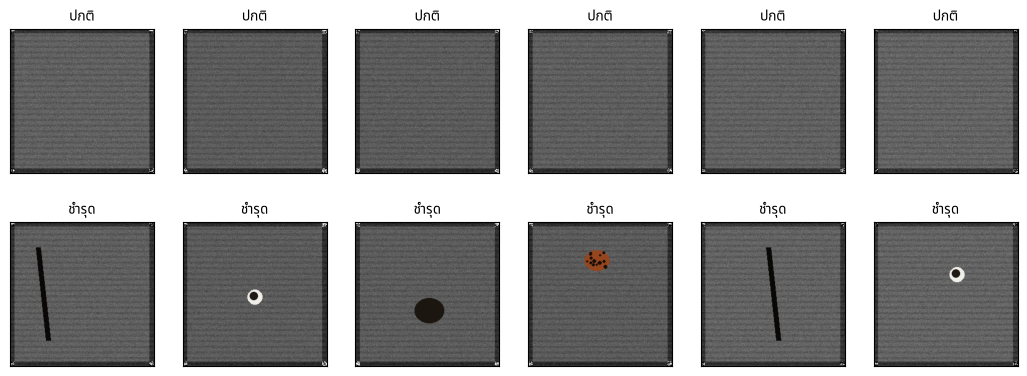

In [4]:
import matplotlib.pyplot as plt  # noqa: E402

plt.rcParams["font.family"] = ["DejaVu Sans", "Noto Sans Thai", "Tahoma"]
fig, axes = plt.subplots(2, 6, figsize=(13, 4.6))
for j in range(6):
    axes[0, j].imshow(Image.open(good_paths[j * 5]))
    axes[0, j].set_title("ปกติ", fontsize=10)
    axes[1, j].imshow(Image.open(defect_paths[j * 5]))
    axes[1, j].set_title("ชำรุด", fontsize=10)
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()


## 2. วิธีที่ 1 — PatchCore: สอนจากภาพปกติเท่านั้น (ทักษะ M6)

เทรน = เก็บ feature ของภาพปกติ 40 ใบเข้า memory bank (ไม่มี gradient) →
ให้คะแนนทุกภาพ = ระยะ kNN ของ patch ที่แปลกที่สุด


In [5]:
import logging  # noqa: E402
import warnings  # noqa: E402

warnings.filterwarnings("ignore")
logging.getLogger("lightning").setLevel(logging.ERROR)

import torch  # noqa: E402
from anomalib.data import Folder  # noqa: E402
from anomalib.engine import Engine  # noqa: E402
from anomalib.models import Patchcore  # noqa: E402

torch.manual_seed(SEED)
datamodule = Folder(
    name="capstone_a",
    root=str(OUT),
    normal_dir="good",
    abnormal_dir="defect",
    val_split_mode="from_test",
    val_split_ratio=0.3,
    num_workers=0,
    seed=SEED,
)
model = Patchcore(
    layers=("layer2", "layer3"),
    num_neighbors=3,
    post_processor=False,
    visualizer=False,
)
engine = Engine(
    accelerator="cpu",
    max_epochs=1,
    logger=False,
    default_root_dir=str(ROOT / "data" / "capstone_a_results"),
    enable_progress_bar=False,
)
print("ตั้งค่าครบ — เทรนในเซลล์ถัดไป")


ตั้งค่าครบ — เทรนในเซลล์ถัดไป


In [6]:
engine.fit(model=model, datamodule=datamodule)


GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


40 hidden files found in /Users/utarn/projects/ml-metrology/.claude/worktrees/issue-33/data/capstone_a/good. Please make sure this is intended.


40 hidden files found in /Users/utarn/projects/ml-metrology/.claude/worktrees/issue-33/data/capstone_a/defect. Please make sure this is intended.


...

Selecting Coreset Indices.:  93%|█████████▎| 3050/3275 [00:04<00:00, 678.85it/s]

Selecting Coreset Indices.:  96%|█████████▌| 3130/3275 [00:04<00:00, 713.11it/s]

Selecting Coreset Indices.:  98%|█████████▊| 3210/3275 [00:04<00:00, 736.85it/s]

Selecting Coreset Indices.: 100%|██████████| 3275/3275 [00:04<00:00, 696.98it/s]

`Trainer.fit` stopped: `max_epochs=1` reached.


In [7]:
from torchvision.transforms.v2.functional import to_dtype  # noqa: E402
from torchvision.transforms.v2.functional import to_image  # noqa: E402


def prep(path: str) -> torch.Tensor:
    """โหลดภาพ 1 ใบ → tensor ที่โมเดลคาดหวัง (256×256, normalized)."""
    img = to_image(Image.open(path).convert("RGB"))
    return model.pre_processor(to_dtype(img, torch.float32, scale=True))


def score_paths(paths: list[str], batch_size: int = 8):
    """ให้คะแนนภาพหลายใบ → (scores, anomaly maps ต่อใบ)."""
    scores, maps = [], []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(paths), batch_size):
            batch = torch.stack(
                [prep(p) for p in paths[i:i + batch_size]]
            )
            out = model(batch)
            scores.append(out.pred_score)
            maps.append(out.anomaly_map.squeeze(1))
    return torch.cat(scores).numpy(), torch.cat(maps).numpy()


s_good, _ = score_paths([str(p) for p in good_paths])
s_def, maps_def = score_paths([str(p) for p in defect_paths])
print("คะแนนภาพปกติ (8 ใบแรก):", np.round(s_good[:8], 0))
print("คะแนนภาพชำรุด(8 ใบแรก):", np.round(s_def[:8], 0))


คะแนนภาพปกติ (8 ใบแรก): [182. 154. 187. 171. 174. 187. 198. 175.]
คะแนนภาพชำรุด(8 ใบแรก): [258. 245. 501. 228. 245. 244. 496. 236.]


AUC = 1.000   threshold (p95 ของภาพปกติ) = 193
TP=40  FN=0  FP=2  TN=38  →  accuracy = 0.97


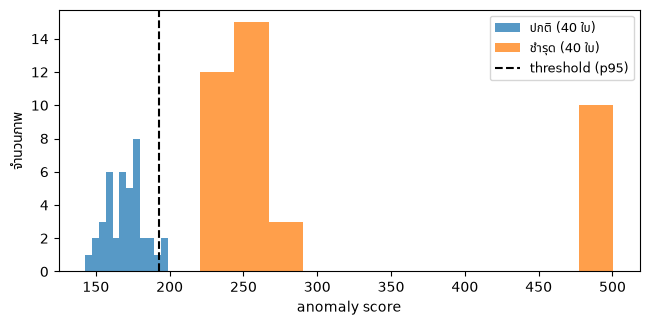

In [8]:
from sklearn.metrics import roc_auc_score  # noqa: E402

y_true = [0] * len(s_good) + [1] * len(s_def)
y_score = np.concatenate([s_good, s_def])
auc = roc_auc_score(y_true, y_score)
THRESHOLD = float(np.percentile(s_good, 95))
print(f"AUC = {auc:.3f}   threshold (p95 ของภาพปกติ) = {THRESHOLD:.0f}")

tp = int((s_def > THRESHOLD).sum())
fn = int(len(s_def) - tp)
fp = int((s_good > THRESHOLD).sum())
tn = int(len(s_good) - fp)
print(f"TP={tp}  FN={fn}  FP={fp}  TN={tn}"
      f"  →  accuracy = {(tp + tn) / (len(s_good) + len(s_def)):.2f}")

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.hist(s_good, bins=12, alpha=0.75, label=f"ปกติ ({len(s_good)} ใบ)")
ax.hist(s_def, bins=12, alpha=0.75, label=f"ชำรุด ({len(s_def)} ใบ)")
ax.axvline(THRESHOLD, color="k", ls="--", lw=1.5, label="threshold (p95)")
ax.set_xlabel("anomaly score")
ax.set_ylabel("จำนวนภาพ")
ax.legend(fontsize=9)
plt.show()


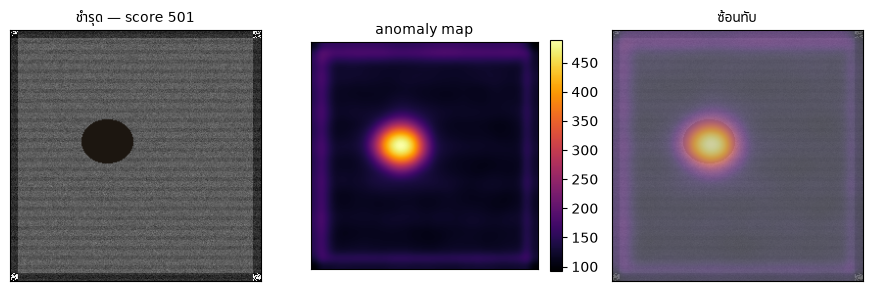

In [9]:
i_top = int(np.argmax(s_def))
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
img = Image.open(defect_paths[i_top]).convert("RGB")
m = maps_def[i_top]
axes[0].imshow(img)
axes[0].set_title(f"ชำรุด — score {s_def[i_top]:.0f}", fontsize=10)
im = axes[1].imshow(m, cmap="inferno")
axes[1].set_title("anomaly map", fontsize=10)
axes[2].imshow(img, alpha=0.45)
axes[2].imshow(m, cmap="inferno", alpha=0.55)
axes[2].set_title("ซ้อนทับ", fontsize=10)
fig.colorbar(im, ax=axes[1], fraction=0.046)
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()


## 3. วิธีที่ 2 — Transfer learning: MobileNetV3 frozen + head (ทักษะ M1)

คราวนี้เรา **มี label ทั้งสองฝั่ง** จึงทำ supervised classifier ได้ —
ยืม backbone จาก ImageNet (freeze) ดึง feature 576 มิติต่อภาพ แล้วเทรน head
เล็กด้วย LogisticRegression (ทักษะตารางจากคอร์ส DS)


In [10]:
import torch.nn as nn  # noqa: E402
import torchvision.models as tvm  # noqa: E402

# to_dtype / to_image ถูก import ไว้แล้วตั้งแต่หัวข้อ 2
mob = tvm.mobilenet_v3_small(
    weights=tvm.MobileNet_V3_Small_Weights.IMAGENET1K_V1
)
backbone = nn.Sequential(mob.features, mob.avgpool, nn.Flatten())
for p in backbone.parameters():
    p.requires_grad_(False)
backbone.eval()


def features(paths, size=96, bs=64):
    """รายชื่อไฟล์ภาพ → เวกเตอร์ 576 มิติ (frozen MobileNetV3)."""
    out = []
    with torch.no_grad():
        for i in range(0, len(paths), bs):
            imgs = [Image.open(p).convert("RGB").resize((size, size))
                    for p in paths[i:i + bs]]
            x = torch.stack([to_image(im) for im in imgs])
            x = to_dtype(x, torch.float32, scale=True)
            out.append(backbone(x))
    return torch.cat(out).numpy()


X_all = features([str(p) for p in good_paths + defect_paths])
y_all = np.array([0] * len(good_paths) + [1] * len(defect_paths))
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(y_all))
tr, te = perm[:48], perm[48:]
print("features:", X_all.shape, "| train/test:", len(tr), "/", len(te))


features: (80, 576) | train/test: 48 / 32


transfer learning — accuracy = 1.000   ROC AUC = 1.000


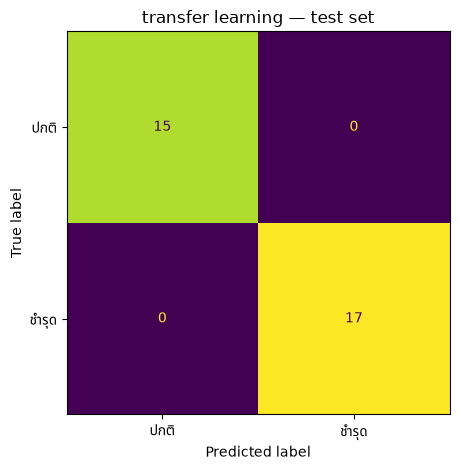

In [11]:
from sklearn.linear_model import LogisticRegression  # noqa: E402
from sklearn.metrics import (ConfusionMatrixDisplay,  # noqa: E402
                             accuracy_score, roc_auc_score)

clf = LogisticRegression(max_iter=1000).fit(X_all[tr], y_all[tr])
pred = clf.predict(X_all[te])
proba = clf.predict_proba(X_all[te])[:, 1]
acc_tl = accuracy_score(y_all[te], pred)
auc_tl = roc_auc_score(y_all[te], proba)
print(f"transfer learning — accuracy = {acc_tl:.3f}   "
      f"ROC AUC = {auc_tl:.3f}")
ConfusionMatrixDisplay.from_predictions(
    y_all[te], pred, display_labels=["ปกติ", "ชำรุด"], colorbar=False,
)
plt.title("transfer learning — test set")
plt.tight_layout()
plt.show()


## 4. เทียบสองวิธี — ต่างกันตรง "ข้อมูลที่ต้องมี" ไม่ใช่แค่ตัวเลข

วิธีชนะกันในตัวเลขได้ แต่คำถามของ capstone คือ **เงื่อนไขจริงของทีมเอนไปทางไหน**
— ในห้องแล็บจริง ภาพ "ชำรุด" มักหายาก/แพง ส่วนภาพ "ปกติ" มักมีอยู่แล้ว


In [12]:
import pandas as pd  # noqa: E402

summary = pd.DataFrame({
    "วิธี": ["PatchCore (M6)", "Transfer learning (M1)"],
    "ต้องมี label ชำรุด?": ["ไม่ต้อง — ใช้ภาพปกติเท่านั้น", "ต้องมี"],
    "อธิบายจุดที่ผิดได้ไหม": [
        "ได้ — anomaly map ชี้จุดชำรุดบนภาพเลย",
        "ต้องพึ่ง Grad-CAM (M7)",
    ],
    "ผลงานนี้": [
        f"AUC = {auc:.3f} (ทั้ง 80 ใบ)",
        f"accuracy = {acc_tl:.3f} (test 32 ใบ)",
    ],
})
print(summary.to_string(index=False))


                  วิธี          ต้องมี label ชำรุด?                 อธิบายจุดที่ผิดได้ไหม                      ผลงานนี้
        PatchCore (M6) ไม่ต้อง — ใช้ภาพปกติเท่านั้น ได้ — anomaly map ชี้จุดชำรุดบนภาพเลย      AUC = 1.000 (ทั้ง 80 ใบ)
Transfer learning (M1)                       ต้องมี                ต้องพึ่ง Grad-CAM (M7) accuracy = 1.000 (test 32 ใบ)


## 5. ทางทีมต่อยอด — รวมถึง "ข้อมูลจริงของทีม" (bring-your-own)

**ใช้รูปถ่ายจริงของทีม (แนวทางเดียวกับ exercise M6):**

1. เลือกวัตถุที่มี "หน้าตาปกติ" ซ้ำ ๆ ได้ — ชิ้นงาน, เครื่องมือวัด, ผิวเครื่องจักร
2. พื้นหลังเรียบสีเดิมทุกครั้ง · แสงคงที่ · มุม/ระยะคงที่ — รายละเอียดเต็ม
   ใน `../../module6_patchcore_anomaly/exercise.ipynb`
3. ภาพปกติ ≥ 20 ใบ (ยิ่งมากยิ่งดี) · ภาพชำรุดถ้าหาได้ ให้ทำวิธีที่ 2 คู่กัน
4. **ระวัง leakage แบบง่ายที่สุด:** ถ้าถ่ายหลายล็อต (วัน/เวลา/ตำแหน่งต่างกัน)
   ต้องแบ่ง train/test ที่ระดับ "ล็อต" — ไม่ใช่สุ่มภาพปนกัน (ภาพถ่ายล็อตเดียว
   ใกล้เคียงกันจนทำนายผ่านหมด แต่ไปไม่รอดโลกจริง)
5. อยากลองกับ **Fashion-MNIST** แทนก็ได้ — สลับข้อมูลตามแบบ M1 แล้วตีความ
   "ชำรุด" ใหม่เป็น class คู่ที่เลือก (เช่น shirt vs ankle-boot)

**ขยายคุณภาพ:** ปรับ `num_neighbors` / `coreset_sampling_ratio` (exercise M6 ข้อ 2)
· ลอง backbone อื่นของ anomalib · ทำ localization metric ถ้ามี mask จริง

## สิ่งที่ผลงานต้องมี (ตรวจด้วย rubric)

1. โมเดลอย่างน้อยหนึ่งวิธี เทรนด้วยมือของทีม (Restart & Run All ผ่าน)
2. การวัดผลซื่อสัตย์: split แยกล็อตถ่าย · confusion matrix + AUC/accuracy
   พร้อมอ่านค่าจากกราฟได้
3. อธิบายการเลือกวิธีจากเงื่อนไขข้อมูล (มี/ไม่มี label ชำรุด, จำนวนภาพ)
4. ย่อหน้าข้อจำกัด: กรณีที่โมเดลยังพลาด (ดู heatmap ประกอบ) + สิ่งที่จะทำต่อ
5. สไลด์ 10 นาที — โครงตาม `rubric.md`
